In [1]:
# z. B.:
# 8 Wohneinheiten a 100 m²
# Gesamtwohnfläche: ca. 800 m²
# test
# Hallo Jan

In [2]:
import pypsaheat as ph
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


In [3]:
# ------------------------------------------------------------
# 1) Allgemeine Einstellungen
# ------------------------------------------------------------

# Wir simulieren ein Jahr in Stundenauflösung
N_HOURS = 8760
snapshots = range(N_HOURS)

# HeatNetwork anlegen und Snapshots setzen
n = ph.HeatNetwork()
n.set_snapshots(snapshots)

In [4]:
# ------------------------------------------------------------
# Lasten laden
# stündliche Daten laut Npro für folgende Annahmen:
# 800 m² Nutzfläche
# Spezifischer Raumwärmebedarf 66 kWh/m²/Jahr
# Trinkwarmwasser spezifischer Jahresbedarf 20 kWh/m²/Jahr
# Nutzerstrom spezifischer Jahresbedarf 22 kWh/m²/Jahr
# ------------------------------------------------------------

df = pd.read_csv(
    "../Input_Data/Archiv/Lastprofil_Erste_Annahmen.csv",
    sep=";",
    decimal=","
)

# Wochentag ("Mo, ", "Di, ") abschneiden
zeit_str = df["Zeit"].str[4:]      # -> "01.01. 00:00"

# In datetime umwandeln
df["Zeit"] = pd.to_datetime(zeit_str, format="%d.%m. %H:%M")

# OPTIONAL: Jahr setzen (intern, für nicer Plot, aber unsichtbar) - Npro hatte kein Jahr angegeben: Mo, 01.01. 00:00 - sonst setzt Pandas das Default Jahr 1900
df["Zeit"] = df["Zeit"].apply(lambda d: d.replace(year=2025))

# df.dtypes  # zum Checken der Datentypen
df.head()


,Zeit,Gesamtwärmebedarf (kW),Raumwaerme (kW),Trinkwarmwasser (kW),Strombedarf (kW)
0,2025-01-01 00:00:00,2.9,2.0,0.9,1.3
1,2025-01-01 01:00:00,1.6,1.1,0.5,1.2
2,2025-01-01 02:00:00,1.2,1.0,0.3,1.0
3,2025-01-01 03:00:00,1.2,1.0,0.1,1.0
4,2025-01-01 04:00:00,1.3,1.0,0.3,0.9


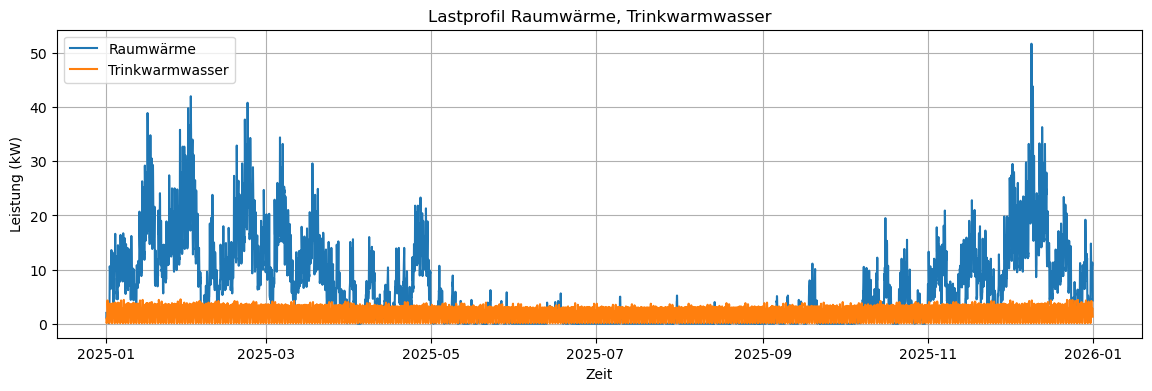

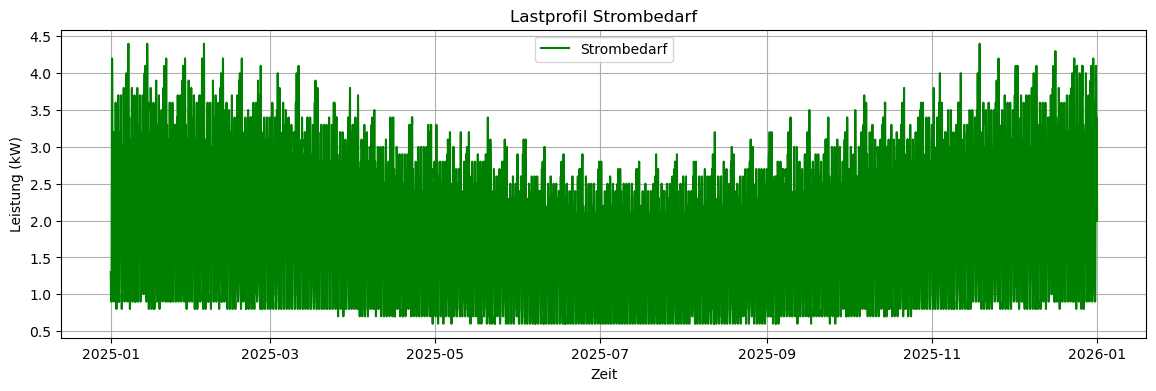

In [5]:
# ------------------------------------------------------------
# Plot der Lasten
# ------------------------------------------------------------
# Wärmebedarf
plt.figure(figsize=(14,4))
plt.plot(df["Zeit"], df["Raumwaerme (kW)"], label="Raumwärme")
plt.plot(df["Zeit"], df["Trinkwarmwasser (kW)"], label="Trinkwarmwasser")

plt.legend()
plt.title("Lastprofil Raumwärme, Trinkwarmwasser")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.show()

# Strombedarf
plt.figure(figsize=(14,4))
plt.plot(df["Zeit"], df["Strombedarf (kW)"], label="Strombedarf", color="green")
plt.legend()
plt.title("Lastprofil Strombedarf")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.show()

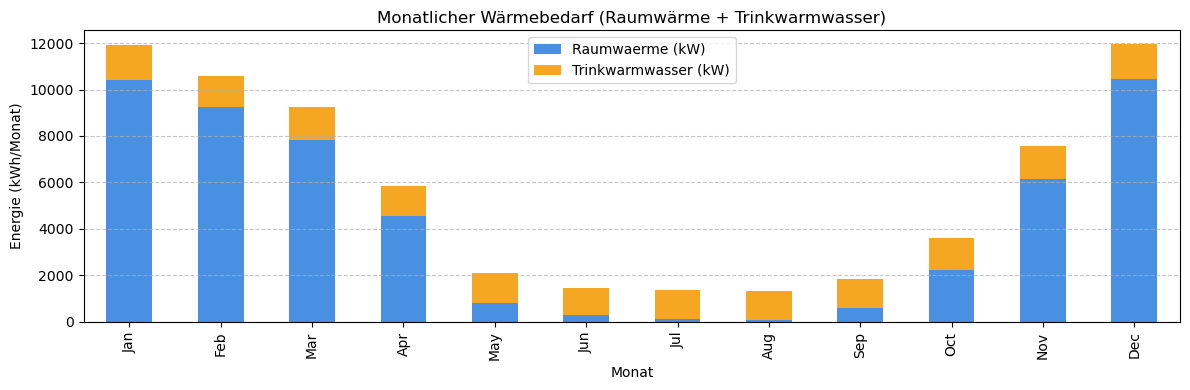

In [6]:
# ------------------------------------------------------------
# Monats-Balkendiagramm statt Linienplot
# ------------------------------------------------------------

df_plot = df.set_index("Zeit")

# Monatswerte berechnen (kWh/Monat)
monthly = df_plot.resample("ME")[["Raumwaerme (kW)", "Trinkwarmwasser (kW)"]].sum()

# Monatsnamen schöner formatieren
monthly.index = monthly.index.strftime("%b")

# Gestapeltes Balkendiagramm (wie in NPro)
ax = monthly.plot(
    kind="bar",
    figsize=(12,4),
    stacked=True,
    color=["#4A90E2", "#F5A623"]  # optionale Farben
)

ax.set_title("Monatlicher Wärmebedarf (Raumwärme + Trinkwarmwasser)")
ax.set_xlabel("Monat")
ax.set_ylabel("Energie (kWh/Monat)")
ax.grid(axis="y", alpha=0.7, linestyle="--")

plt.tight_layout()
plt.show()




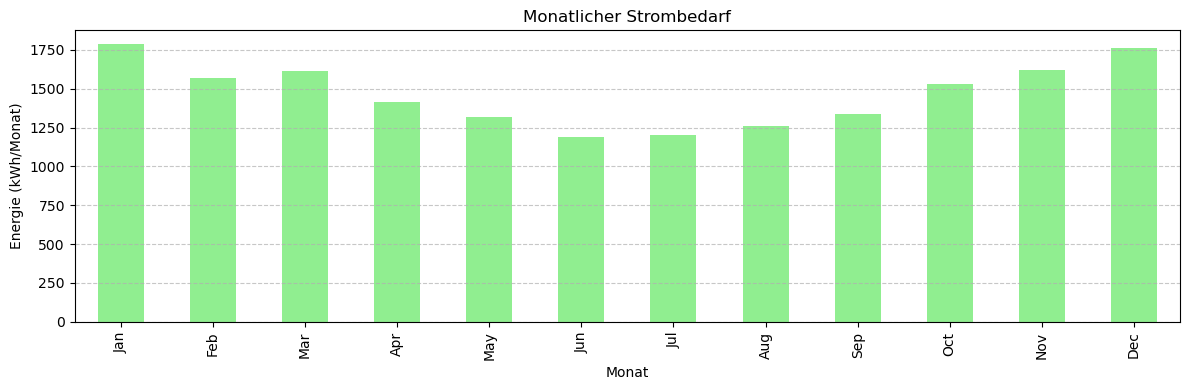

In [7]:
# ------------------------------------------------------------
# Monats-Balkendiagramm Strombedarf
# ------------------------------------------------------------

# Monatswerte berechnen (kWh/Monat)
monthly_elec = df_plot.resample("ME")[["Strombedarf (kW)"]].sum()

# Monatsnamen setzen
monthly_elec.index = monthly_elec.index.strftime("%b")

# Plot
ax = monthly_elec.plot(
    kind="bar",
    figsize=(12,4),
    color="lightgreen",
    legend=False
)

ax.set_title("Monatlicher Strombedarf")
ax.set_xlabel("Monat")
ax.set_ylabel("Energie (kWh/Monat)")
ax.grid(axis="y", alpha=0.7, linestyle="--")

plt.tight_layout()
plt.show()


In [8]:
# PV Erzeugungsprofil
# Annahmen: Dataset MERRA-2 (global), 2019, capacity 1kW, system loss 0.1 , Tilt 35°, Azimuth 180°, included raw data
pv = pd.read_csv(
    "../Input_Data/ninja_pv_50.9384_6.9600_corrected.csv",
    skiprows=3,
    parse_dates=["local_time"],
)

pv = pv.set_index("local_time")

pv = pv.rename(columns={
    "electricity": "pv_electricity",
    "irradiance_direct": "direct",
    "irradiance_diffuse": "diffuse",
    "temperature": "temp"
})

pv.head(100)

,time,pv_electricity,direct,diffuse,temp
local_time,,,,,
2019-01-01 01:00:00,2019-01-01 00:00,0.0,0.0,0.0,6.294
2019-01-01 02:00:00,2019-01-01 01:00,0.0,0.0,0.0,6.003
2019-01-01 03:00:00,2019-01-01 02:00,0.0,0.0,0.0,5.710
2019-01-01 04:00:00,2019-01-01 03:00,0.0,0.0,0.0,5.540
2019-01-01 05:00:00,2019-01-01 04:00,0.0,0.0,0.0,5.458
...,...,...,...,...,...
2019-01-05 00:00:00,2019-01-04 23:00,0.0,0.0,0.0,2.187
2019-01-05 01:00:00,2019-01-05 00:00,0.0,0.0,0.0,2.378
2019-01-05 02:00:00,2019-01-05 01:00,0.0,0.0,0.0,2.531


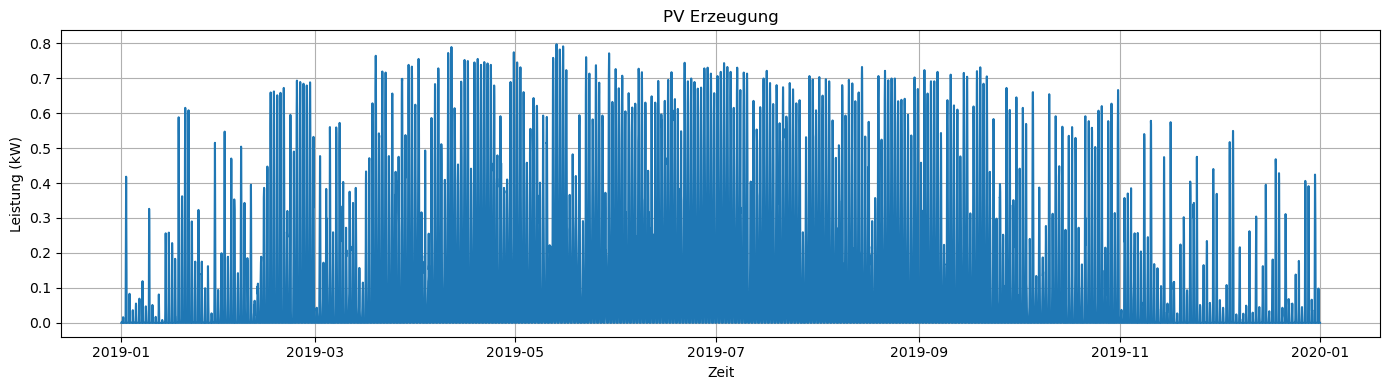

In [9]:
# Erzeugungsprofil PV plotten
plt.figure(figsize=(14,4))
plt.plot(pv.index, pv["pv_electricity"], label="PV (kW)")
plt.title("PV Erzeugung")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
# ------------------------------------------------------------
# Außentemperaturdaten laden
# ------------------------------------------------------------

weather = pd.read_csv(
    "../Input_Data/ninja_weather_50.9384_6.9600_2019_uncorrected.csv",
    skiprows=3,
    parse_dates=["local_time"]
)

# Index setzen
weather = weather.set_index("local_time")

# Umbenennen: t2m → T_outdoor
weather = weather.rename(columns={"t2m": "T_outdoor"})

# Nur Temperatur extrahieren
T_outdoor = weather["T_outdoor"]

T_outdoor.head()

local_time
2019-01-01 01:00:00    6.294
2019-01-01 02:00:00    6.003
2019-01-01 03:00:00    5.710
2019-01-01 04:00:00    5.540
2019-01-01 05:00:00    5.458
Name: T_outdoor, dtype: float64

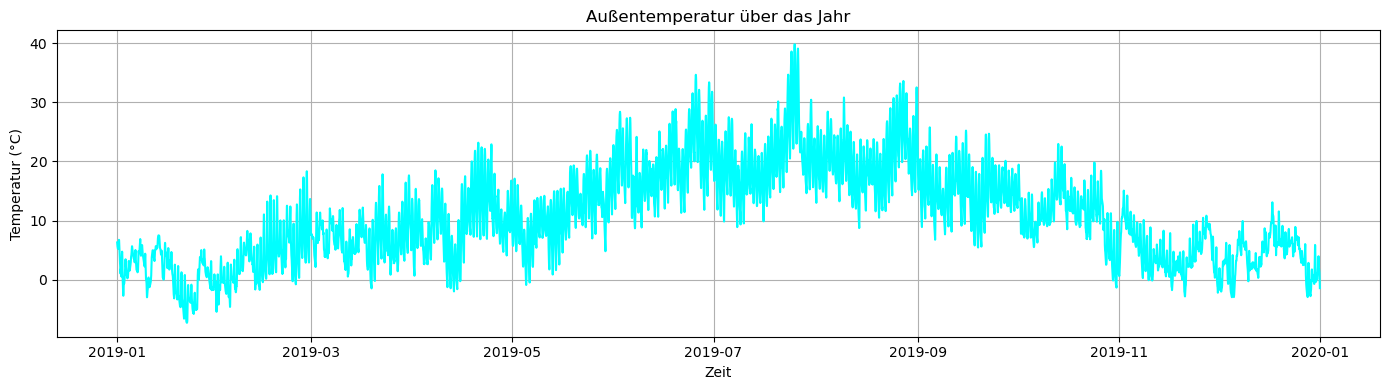

In [11]:
# -------------------------------------------
# Außentemperatur plotten
# -------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(weather.index, weather["T_outdoor"], label="Außentemperatur (°C)", color="cyan")

plt.title("Außentemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
### Auslegung der Komponenten

In [13]:
#Strom
#capital_cost_pv = 87500 # €/MW as annuity
PV_power        =   13      # kWp
grid_power      =   70      # kW Hausanschluss Leistung
grid_cost       =   0.35    # €/kWh Kosten für Netzstrombezug
feed_in_tariff  =   -0.08   # €/kWh (Beispiel)

capital_cost_battery    = 60000 #€/MWh as annuity
Battery_marginal_cost   = 0.0     # Grenzgestehungskosten für Batterie

#Wärme
Store_height    =   1.5     #m
Store_base      =   0.4     #m²
Store_T_layers  =   [60, 56, 52, 48, 30]      #°C Temperaturschichten; !! Hier kann die Anzahl und die Temperatur der Schichten angepasst werden !!
# dynamisch anpassen


HP_power        =   65      #kW Wärmepumpenleistung
HE_power        =   15      #kW Heizstableistung


# ------------------------------------------------------------
# Heizkörper vs. Fußbodenheizung über Heizkurve (flow_temperature)
# ------------------------------------------------------------

# Flag: True = Heizkörper, False = Fußbodenheizung
use_radiators = False

T_vorlauf = 55.0 if use_radiators else 30.0
T_gradient = 10/15 # wie stark die Vorlauftemperatur mit der Außentemp. steigt

# Heizkurve berechnen (PyPSA_heat-Funktion aus der Übung) - hier wird die vorlauftemperatur verwendet!
T_flow = ph.physics.flow_temperature(T_vorlauf, T_gradient, T_outdoor)

Store_T_return  = T_vorlauf - 10      #°C Rücklauftemperatur

heating_cutoff = 15.0  # °C  # Außentemperatur, ab der nicht mehr geheizt wird
heat_on = T_outdoor <= heating_cutoff
T_flow_min = Store_T_return + 5  # Mindestvorlauftemperatur (5°C über Rücklauftemp)
T_flow = T_flow.clip(lower=T_flow_min)
T_flow = T_flow.where(heat_on, T_flow_min)

T_flow


local_time
2019-01-01 01:00:00    25.80
2019-01-01 02:00:00    26.00
2019-01-01 03:00:00    26.19
2019-01-01 04:00:00    26.31
2019-01-01 05:00:00    26.36
                       ...  
2019-12-31 20:00:00    29.03
2019-12-31 21:00:00    29.23
2019-12-31 22:00:00    29.74
2019-12-31 23:00:00    30.38
2020-01-01 00:00:00    30.96
Name: T_outdoor, Length: 8760, dtype: float64

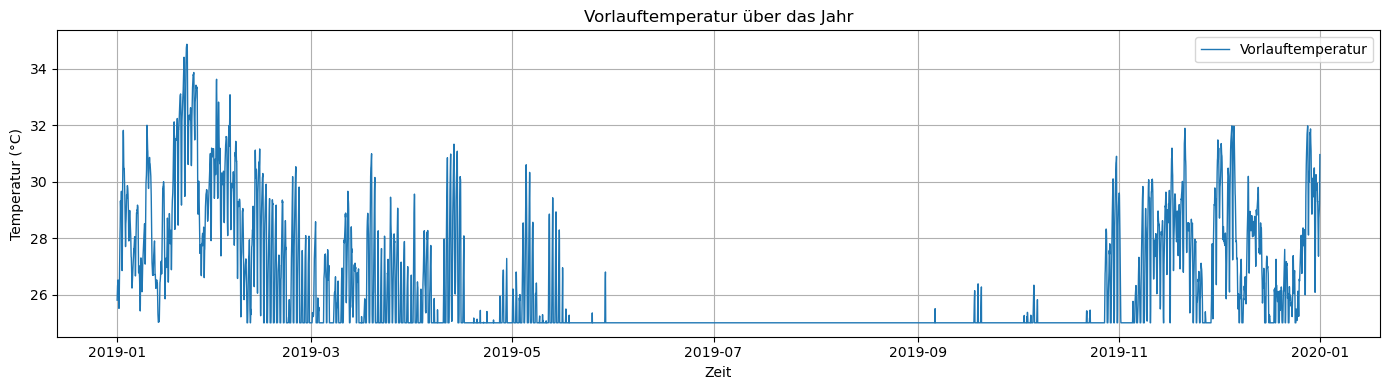

In [14]:
plt.figure(figsize=(14,4))
plt.plot(weather.index, T_flow, label="Vorlauftemperatur", linewidth=1)

plt.title("Vorlauftemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
# ---------------------------------------------
# Energiesystem
# ---------------------------------------------

# ------------------------------------------------------------
# Elektrisches System
# ------------------------------------------------------------
# # Strombus
n.add("Bus", "electricity_grid")            # Hausnetz (Last + Import)
n.add('Bus', name = 'electricity_infeed')   # PV-Seite (Erzeugung + Export)

# Netz-Generator (Strombezug aus dem Hausnetz)
n.add(
    "Generator",
    name="grid_import",
    bus="electricity_grid",
    p_nom=grid_power,
    marginal_cost=grid_cost # €/kwh  # Literaturwert nehmen!
)

# PV-Generator
n.add(
    "Generator",
    name="pv_generation",
    bus="electricity_infeed",
    p_nom=PV_power,                             # kW_peak,
    p_max_pu=pv["pv_electricity"].values,
    marginal_cost=0.0
)

# Einspeisung (Export) von der PV-Seite
n.add(
    'Generator',
    name = 'pv_infeed',
    bus = 'electricity_infeed',
    p_nom =PV_power,                    # max Exportleistung (z.B. PV_power oder Hausanschluss)
    marginal_cost =feed_in_tariff,      #
    sign = -1)                          #  <-- macht es zur Senke (Energie Export)

# Link: PV -> Hausnetz
n.add(
    "Link",
    name="electricity_link",
    bus0="electricity_infeed",
    bus1="electricity_grid",
    p_nom=PV_power,
    efficiency=1.0
)


# ------------------------------------------------------------
# Batteriespeicher
# ------------------------------------------------------------

# Battery-Store
n.add(
    "StorageUnit",
    name = "store_el",
    bus = "electricity_grid",
    e_nom_extendable = True,
    e_cyclic = True,
    standing_loss = 0.01,                        # Verluste pro Stunde [%] (Platzhalter)
    capital_cost = capital_cost_battery,         # Investitionskosten €/kWh (Platzhalter)
    lifetime=15,                                 # Jahre (Platzhalter)
    build_year=2025,                             # Baujahr (Platzhalter)
    efficiency_store= 0.95,                      #
    efficiency_dispatch=0.95,
)


# ------------------------------------------------------------
# Wärmespeicher
# ------------------------------------------------------------
# Konstant geschichteter Speicher:
# - constant="temperature"
# - T_layer: feste Temperaturschichten
# - T_return: Rücklauftemperatur
# - cyclic=True: Speicherzustand am Ende = am Anfang

n.add(
    "HeatStore",
    name="hs_mfh",              # # hs = heat store (Wärmespeicher)
    constant="temperature",
    height=Store_height,                # Höhe [m] (Platzhalter)
    base=Store_base,                  # Grundfläche [m²] → Volumen ~ 4 m³
    T_layer=Store_T_layers,  # Temperaturschichten [°C]
    T_return=Store_T_return,               # Rücklauftemperatur [°C]
    V_initial=[0,0,0,0,0],
    cyclic=True,               # Anfangs- und Endzustand identisch (V_initial)
    T_amb=20.0,                # Umgebungstemperatur des Speichers [°C]
    U_wall=0.2                 # U-Wert der Dämmung [W/(m²*K)] (Platzhalter)
)


# ------------------------------------------------------------
# Wärmepumpe (HeatPump)
# ------------------------------------------------------------

n.add(
    "HeatPump",
    name="hp_mfh",
    bus0="electricity_grid",     # elektrische Seite am Strombus
    heat_store="hs_mfh",    # thermische Seite am Wärmespeicher
    p_nom=HP_power,         # thermische Nennleistung in kW
    T_source=T_outdoor.values,    # Quelltemperatur = Außentemperatur (Luft-Wasser-Wärmepumpe)
    T_max = 65,
    heat_source="air"      # Luft als Quelle
)

# ------------------------------------------------------------
# Elektrischer Heizstab (HeatingElement)
# ------------------------------------------------------------

n.add(
    "HeatingElement",
    name="backup_heater",
    bus0="electricity_grid",
    heat_store="hs_mfh",
    p_nom=HE_power, # elektrische Nennleistung in kW
    efficiency=0.95
)

# ------------------------------------------------------------
# Loads des Energiesystems definieren
# ------------------------------------------------------------
p_el = df["Strombedarf (kW)"].values
p_raumwaerme = df["Raumwaerme (kW)"].values
p_warmwasser = df["Trinkwarmwasser (kW)"].values

# Elektrische Last
n.add(
    "Load",
    name="el_demand",
    bus="electricity_grid",
    p_set=p_el
)

# Raumwärme
n.add(
    "HeatLoad",
    name="Raumwaerme",
    heat_store="hs_mfh",
    p_set=p_raumwaerme,
    T_demand=T_flow.values
)

# Warmwasser
n.add(
    "HeatLoad",
    name="dhw",
    heat_store="hs_mfh",
    p_set=p_warmwasser,
    T_demand=60.0
)




C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dty

Index(['electricity_grid', 'electricity_infeed'], dtype='object', name='Bus')
Index(['electricity_link'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2694931


INFO:gurobipy:Set parameter LicenseID to value 2694931


...

INFO:gurobipy:


Solved in 98457 iterations and 1.26 seconds (1.68 work units)


INFO:gurobipy:Solved in 98457 iterations and 1.26 seconds (1.68 work units)


Optimal objective  1.149409637e+04


INFO:gurobipy:Optimal objective  1.149409637e+04
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 201480 primals, 411720 duals
Objective: 1.15e+04
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, HeatStore-hs_mfh-fix-volume-upper, HeatStore-hs_mfh-fix-volume-lower, HeatStore-hs_mfh-layer_balance, HeatStore-hs_mfh-internal-lower, HeatingElement-backup_heater-fix-p-lower, HeatingElement-backup_heater-fix-p-upper, HeatPump-hp_mfh-fix-p-lower, HeatPump-hp_mfh-fix-p-upper, HeatPump-hp_mfh-fix-p-layer-lower, HeatPump-hp_mfh-fix-p-layer-upper were not assigned to the

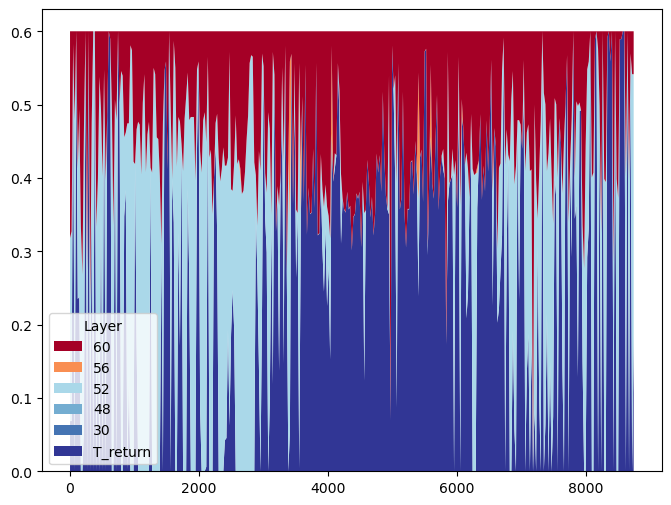

In [16]:
# ------------------------------------------------------------
# Optimierung & Plot
# ------------------------------------------------------------
#Hello
n.optimize(solver_name="gurobi")


sns_to_plot = snapshots[::24]   # jeden Tag ein Punkt
ph.plot.plot_stratified_heat_store(
    n,
    hs="hs_mfh",
    sns=sns_to_plot
)


In [17]:
# ============================================================
# Energiesystem: Ergebnisse & Kennzahlen
# ============================================================

print("====================================")
print("Energiesystem – Überblick")
print("====================================")

# ------------------------------------------------------------
# 1) Komponenten-Auslegung (Nennleistungen)
# ------------------------------------------------------------

print("\n--- Komponenten ---")

# Generatoren (klassisch)
if "pv_generation" in n.generators.index:
    print("PV Leistung [kW]:", n.generators.loc["pv_generation", "p_nom"])

if "grid_import" in n.generators.index:
    print("Netzanschluss [kW]:", n.generators.loc["grid_import", "p_nom"])

# PyPSA-Heat Komponenten (generic API)
hp_df = n.df("HeatPump")
he_df = n.df("HeatingElement")
hs_df = n.df("HeatStore")

if "hp_mfh" in hp_df.index:
    # je nach Version p_nom oder p_nom_opt (wenn extendable)
    if "p_nom_opt" in hp_df.columns:
        print("Wärmepumpe Leistung [kW_th]:", hp_df.loc["hp_mfh", "p_nom_opt"])
    else:
        print("Wärmepumpe Leistung [kW_th]:", hp_df.loc["hp_mfh", "p_nom"])

if "backup_heater" in he_df.index:
    if "p_nom_opt" in he_df.columns:
        print("Heizstab Leistung [kW_el]:", he_df.loc["backup_heater", "p_nom_opt"])
    else:
        print("Heizstab Leistung [kW_el]:", he_df.loc["backup_heater", "p_nom"])

# Wärmespeicher-Auslegung (Geometrie / Dämmung)
if "hs_mfh" in hs_df.index:
    print("\n--- Wärmespeicher (hs_mfh) ---")
    for col in ["height", "base", "U_wall", "T_return", "T_amb"]:
        if col in hs_df.columns:
            print(f"{col}: {hs_df.loc['hs_mfh', col]}")


Energiesystem – Überblick

--- Komponenten ---
PV Leistung [kW]: 13.0
Netzanschluss [kW]: 70.0
Wärmepumpe Leistung [kW_th]: 65.0
Heizstab Leistung [kW_el]: 15.0

--- Wärmespeicher (hs_mfh) ---
height: 1.5
base: 0.4
U_wall: 0.2
T_return: 20.0
T_amb: 20.0


In [18]:
# Batteriedaten abfragen:

print("StorageUnits vorhanden:", getattr(n, "storage_units", pd.DataFrame()).index.tolist())

if "store_el" in getattr(n, "storage_units", pd.DataFrame()).index:
    print("\nstore_el Parameter:")
    print(n.storage_units.loc["store_el"])
    print("\nstore_el dispatch time series vorhanden?:",
          "store_el" in getattr(n, "storage_units_t", pd.DataFrame()).p.columns)
else:
    print("store_el ist nicht im Network gelandet.")

StorageUnits vorhanden: ['store_el']

store_el Parameter:
attribute
bus                                   electricity_grid
control                                             PQ
type                                                  
p_nom                                              0.0
p_nom_mod                                          0.0
p_nom_extendable                                 False
p_nom_min                                          0.0
p_nom_max                                          inf
p_min_pu                                          -1.0
p_max_pu                                           1.0
p_set                                              0.0
q_set                                              0.0
sign                                               1.0
carrier                                               
marginal_cost                                      0.0
marginal_cost_quadratic                            0.0
capital_cost                                   60000


Wärmepumpe – Auswertung (hp_mfh)


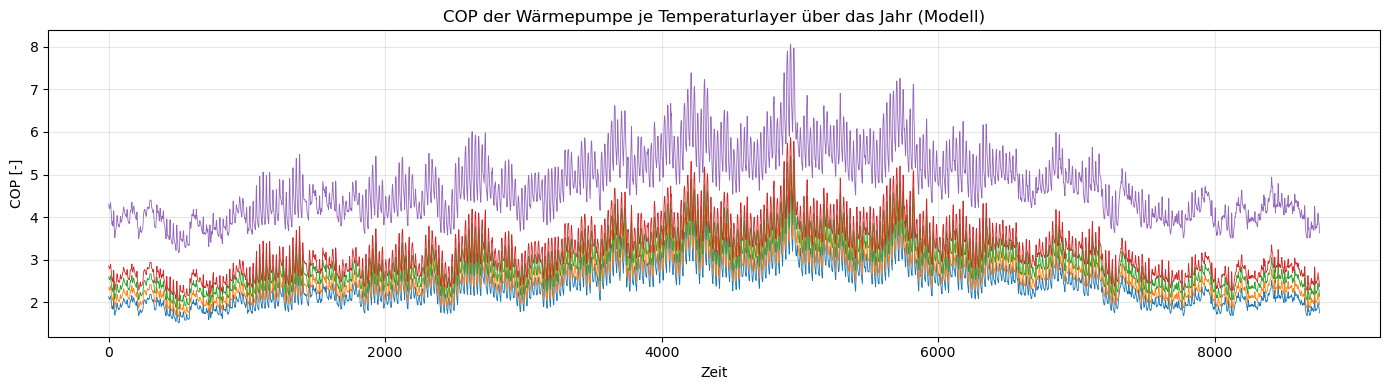


--- Auslegung ---
Thermische Nennleistung p_nom: 65.00 kW_th

--- COP Kennzahlen (physikalisch = p_heat/p_elec) ---
COP Mittelwert: 2.76
COP Median:     2.64
COP Minimum:    1.82
COP Maximum:    6.91

--- Jahresenergien ---
WP Stromverbrauch: 27473.53 kWh_el/a
WP Wärmeerzeugung: 68948.08 kWh_th/a

--- JAZ ---
JAZ_HP (Q_hp / E_hp): 2.510


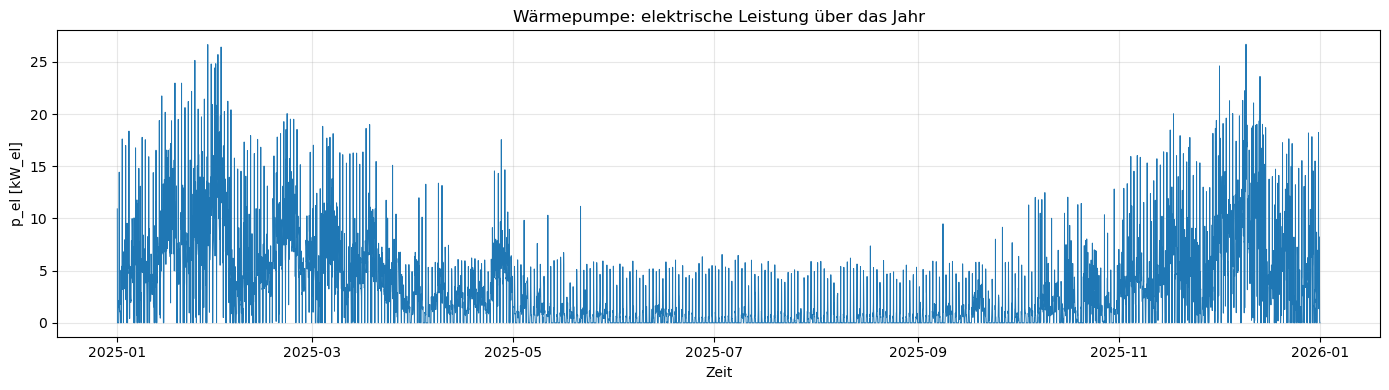

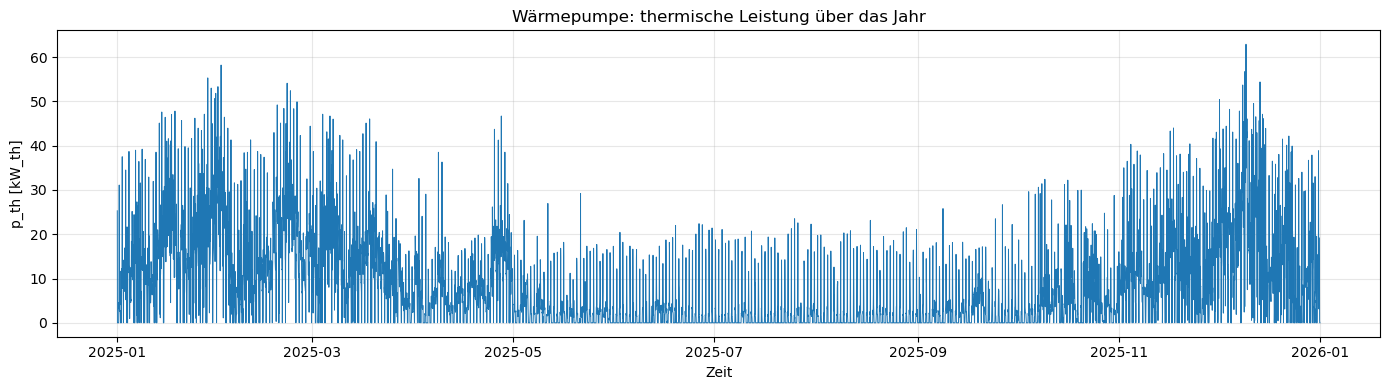

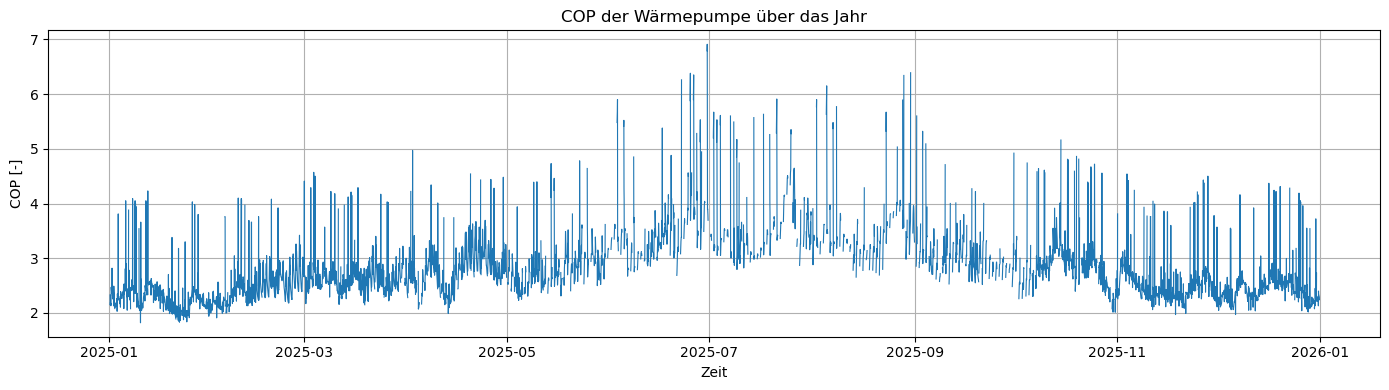

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


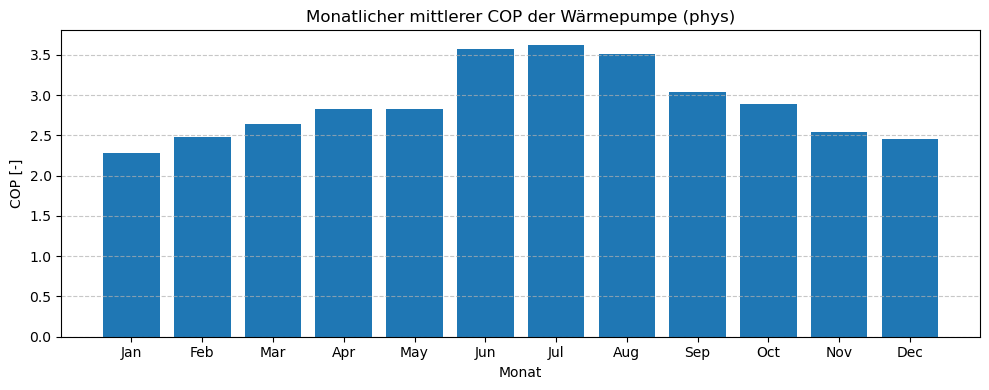

In [19]:
# ============================================================
# Wärmepumpe (hp_mfh): Kennzahlen, COP-Verlauf, JAZ (Layer-korrekt)
# ============================================================

hp_name = "hp_mfh"

hp_df = n.df("HeatPump")        # Tabelle Parameter HP
hp_t  = n.pnl("HeatPump")       # Zeitreihen-Container pro Std. für HP (p_heat, p_elec, COP)

# hp_t =
#   "p_heat":  Zeitreihe(n),
#   "p_elec":  Zeitreihe(n),
#   "COP":     Zeitreihe(n),
#   ...
#   }

print("\n====================================")
print(f"Wärmepumpe – Auswertung ({hp_name})")
print("====================================")

# --- Modellergebnisse der WP  ---
cop_model  = hp_t["COP"][hp_name]         # kommt aus unserem Model und kann mehere Temperaturschichten enthalten
p_el_model = hp_t["p_elec"][hp_name]      # p_el_model = elektrische Leistung der WP
p_th_model = hp_t["p_heat"][hp_name]      # p_th_model = thermische Leistung der WP

# ============================================================
# kurzer Einschub Plot: COP je Temperaturlayer darstellen
# ============================================================

plt.figure(figsize=(14,4))

if isinstance(cop_model, pd.DataFrame):
    # Mehrere Temperaturlayer → jede Spalte wird eine Linie
    plt.plot(cop_model.index, cop_model.values, linewidth=0.6)
    plt.title("COP der Wärmepumpe je Temperaturlayer über das Jahr (Modell)")
else:
    # Nur ein Layer
    plt.plot(cop_model.index, cop_model.values, linewidth=0.8)
    plt.title("COP der Wärmepumpe über das Jahr (Modell)")

plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# ============================================================
# jetzt weiter mit Code
# ============================================================


# --- Zeitindex (für Plot & Resample) ---
time_index = pd.DatetimeIndex(df["Zeit"])   # df = Lastprofil (Raumwärme, Trinkwarmwasser, Strom)
                                            # Zeitspalte aus meinem Lastprofil nehmen und nutze diese hier weiter

# p_heat / p_elec: Gesamtleistung (Summe über Layer, falls nötig)

# Typabfrage mit isinstance(..) = ist p_th_model ein DataFrame (mehere Layer)
# wenn p_th_model ein DataFrame ist, dann summe über alle Layer, sonst nur über 1. Layer - damit # der Layer anpassbar
p_th_total = p_th_model.sum(axis=1) if isinstance(p_th_model, pd.DataFrame) else p_th_model
p_el_total = p_el_model.sum(axis=1) if isinstance(p_el_model, pd.DataFrame) else p_el_model

# optional: Modell-COP als Mittel (nur Info)
# mean(axis=1) bedutet arithmetischer Mittelwert aller Layer-COPs pro Stunde
# Das ist der gemittelte Modell-COP über alle Temperaturschichten.
# cop_model_mean ist der aus dem Modell resultierende, über alle Temperaturlayer gemittelte COP und dient ausschließlich der qualitativen Interpretation, nicht der energetischen Bewertung.
cop_model_mean = cop_model.mean(axis=1) if isinstance(cop_model, pd.DataFrame) else cop_model

# Datetime-Series
# p_el_s = die stündliche elektrische Leistung der WP
# np.asarray(p_el_s, dtype=float) erzwingt numpy-Array-Konvertierung (robuste Statistik)
# pd.series baut daraus eine Zeitreihe - jeder Wert bekommt einen Zeitstempel aus dem time_index
# „Ich nehme Daten aus der Simulation und mache daraus eine saubere, zeitlich zuordenbare Serie.“
# p_el_ts = elektrische Leistung der Wp pro std in pd.series
p_el_ts = pd.Series(np.asarray(p_el_total, dtype=float), index=time_index)
p_th_ts = pd.Series(np.asarray(p_th_total, dtype=float), index=time_index)
cop_model_ts = pd.Series(np.asarray(cop_model_mean, dtype=float), index=time_index)

# Physikalischer COP aus Q/P
# Betriebs COP der WP pro stunde
# p_th_ts = Wärmeleistung der WP (kW_th) pro Stunde
# p_el_ts = Elektrische Leistung der WP (kW_el) pro Stunde
# p_el_ts.replace(0, np.nan) = ersetzt alle Stellen, wo der Stromverbrauch 0 ist, durch NaN.
# „COP ist in diesen Stunden nicht definiert (weil WP aus).“
cop_phys_ts = p_th_ts / p_el_ts.replace(0, np.nan)

# --- Auslegung ---
# wenn es die Spalte p_nom gibt → Wert auslesen
# sonst → None, Schutz falls das Modell p_nom nicht gesetzt ist
P_th_nom_val = float(hp_df.loc[hp_name, "p_nom"]) if "p_nom" in hp_df.columns else None
print("\n--- Auslegung ---")
if P_th_nom_val is not None:
    print(f"Thermische Nennleistung p_nom: {P_th_nom_val:.2f} kW_th")

# --- Kennzahlen (COP phys) ---
# np.nanmean(...), np.nanmedian(...), etc. sind numpy-Funktionen
# float() wandelt Ergebnis in Python Scalar für print(..), weiterrechnen usw.
COP_mean   = float(np.nanmean(cop_phys_ts.values))      # Durchschnittlicher Betriebs-COP
COP_median = float(np.nanmedian(cop_phys_ts.values))    # Median-Betriebs-COP
COP_min    = float(np.nanmin(cop_phys_ts.values))       # Schlechtester Betriebszustand
COP_max    = float(np.nanmax(cop_phys_ts.values))       # Bester Betriebszustand

print("\n--- COP Kennzahlen (physikalisch = p_heat/p_elec) ---")
print(f"COP Mittelwert: {COP_mean:.2f}")
print(f"COP Median:     {COP_median:.2f}")
print(f"COP Minimum:    {COP_min:.2f}")
print(f"COP Maximum:    {COP_max:.2f}")

# --- Jahresenergien ---
E_hp = float(np.nansum(p_el_ts.values))  # kWh_el/a
Q_hp = float(np.nansum(p_th_ts.values))  # kWh_th/a
# .values → NumPy-Array der Zahlen, np.nansum(...) → summiert alles, ignoriert NaNs, float(...) → macht daraus eine normale Zahl

print("\n--- Jahresenergien ---")
print(f"WP Stromverbrauch: {E_hp:.2f} kWh_el/a")
print(f"WP Wärmeerzeugung: {Q_hp:.2f} kWh_th/a")

# --- JAZ Berechnung ---
print("\n--- JAZ ---")
JAZ_hp = (Q_hp / E_hp) if E_hp > 0 else np.nan
print(f"JAZ_HP (Q_hp / E_hp): {JAZ_hp:.3f}")


# --- Ergebnis Plots:  ---

# Wärmepumpe: elektrische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_el_ts.index, p_el_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: elektrische Leistung über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("p_el [kW_el]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: thermische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_th_ts.index, p_th_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: thermische Leistung über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("p_th [kW_th]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: Betriebs COP über das Jahr
plt.figure(figsize=(14,4))
plt.plot(cop_phys_ts.index, cop_phys_ts.values, linewidth=0.8, label="COP phys (Q/P)")
plt.title("COP der Wärmepumpe über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Monatsmittel COP (phys) ---
cop_monthly = cop_phys_ts.resample("ME").mean()
cop_monthly.index = cop_monthly.index.strftime("%b")

plt.figure(figsize=(10,4))
plt.bar(cop_monthly.index, cop_monthly.values)
plt.title("Monatlicher mittlerer COP der Wärmepumpe (phys)")
plt.xlabel("Monat")
plt.ylabel("COP [-]")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()






--- Strombilanz ---
Verbrauch gesamt (HH+WP+HE+BattLaden): 45071 kWh/a
Netzbezug:                             33766 kWh/a
PV-Erzeugung:                          15355 kWh/a
Einspeisung (Export):                  -4050 kWh/a
Batterie Laden:                        0 kWh/a
Batterie Entladen:                     0 kWh/a
Autarkiegrad:                          25.1 %


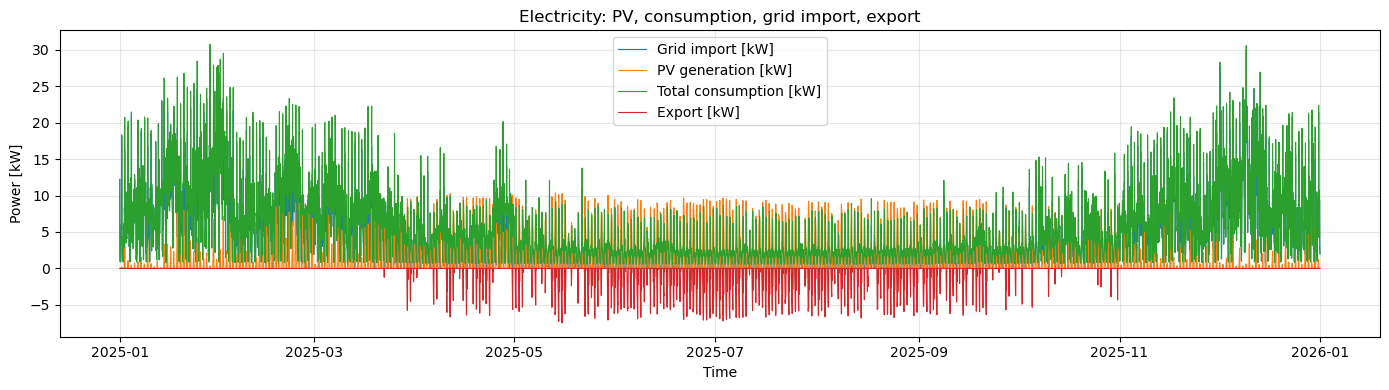

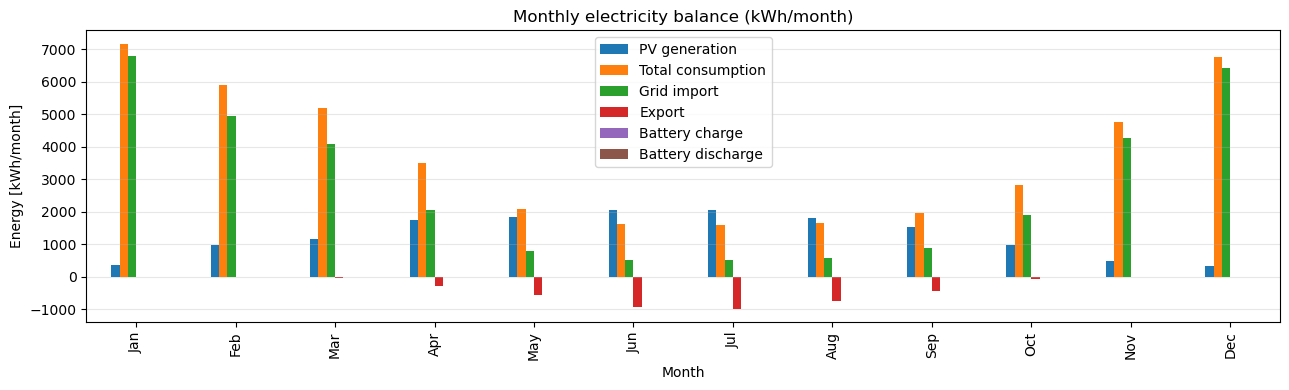

In [20]:
# ================================
#  Strombilanz - Netzbezug - PV Gen. - Einspeisung etc.
# ================================

time_index = pd.DatetimeIndex(df["Zeit"])

# --- 1) PV generation (kW) ---
pv_gen = n.generators_t.p["pv_generation"]  # kW, >=0

# --- 2) Grid import (kW) ---
grid_import = n.generators_t.p["grid_import"]  # kW, >=0

# --- 3) Feed-in / export (kW, make it positive) ---
if "pv_infeed" in n.generators_t.p.columns:
    export = -n.generators_t.p["pv_infeed"]     # kW, >=0
else:
    export = pd.Series(0.0, index=n.snapshots)

# --- 4) Household electric load (kW) ---
load_el = n.loads_t.p["el_demand"]  # kW

# --- 5) Heat pump electric consumption (kW) ---
hp_t = n.pnl("HeatPump")
hp_p_el = hp_t["p_elec"]["hp_mfh"]
hp_p_el_total = hp_p_el.sum(axis=1) if isinstance(hp_p_el, pd.DataFrame) else hp_p_el  # kW

# --- 6) Heating element electric consumption (kW) ---
he_t = n.pnl("HeatingElement")
he_p_el = he_t["p_elec"]["backup_heater"]
he_p_el_total = he_p_el.sum(axis=1) if isinstance(he_p_el, pd.DataFrame) else he_p_el  # kW

# --- 7) Battery (kW): StorageUnit p > 0 discharges to bus, p < 0 charges from bus ---
if "store_el" in getattr(n, "storage_units", pd.DataFrame()).index and \
   "store_el" in getattr(n, "storage_units_t", pd.DataFrame()).p.columns:
    bat_p = n.storage_units_t.p["store_el"]  # kW
    bat_charge = (-bat_p).clip(lower=0)      # kW charging
    bat_discharge = (bat_p).clip(lower=0)    # kW discharging
else:
    bat_charge = pd.Series(0.0, index=n.snapshots)
    bat_discharge = pd.Series(0.0, index=n.snapshots)

# --- Total electric consumption on the grid bus (kW) ---
# This is what must be covered by PV (via link), battery discharge, and grid import.
total_consumption = load_el + hp_p_el_total + he_p_el_total + bat_charge

# --- Energies (kWh) for hourly data: sum of kW values ---
E_grid = float(grid_import.sum())
E_cons = float(total_consumption.sum())
E_pv = float(pv_gen.sum())
E_exp = float(export.sum())
E_bat_chg = float(bat_charge.sum())
E_bat_dis = float(bat_discharge.sum())

autarkiegrad = 1 - (E_grid / E_cons) if E_cons > 0 else np.nan

print("\n--- Strombilanz ---")
print(f"Verbrauch gesamt (HH+WP+HE+BattLaden): {E_cons:.0f} kWh/a")
print(f"Netzbezug:                             {E_grid:.0f} kWh/a")
print(f"PV-Erzeugung:                          {E_pv:.0f} kWh/a")
print(f"Einspeisung (Export):                  {E_exp:.0f} kWh/a")
print(f"Batterie Laden:                        {E_bat_chg:.0f} kWh/a")
print(f"Batterie Entladen:                     {E_bat_dis:.0f} kWh/a")
print(f"Autarkiegrad:                          {autarkiegrad*100:.1f} %")

# --- Plot: power time series ---
plt.figure(figsize=(14,4))
plt.plot(time_index, grid_import.values, label="Grid import [kW]", linewidth=0.8)
plt.plot(time_index, pv_gen.values, label="PV generation [kW]", linewidth=0.8)
plt.plot(time_index, total_consumption.values, label="Total consumption [kW]", linewidth=0.8)
plt.plot(time_index, export.values, label="Export [kW]", linewidth=0.8)
plt.title("Electricity: PV, consumption, grid import, export")
plt.xlabel("Time")
plt.ylabel("Power [kW]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Monthly energy bars (kWh/month) ---
pv_ts   = pd.Series(pv_gen.to_numpy(), index=time_index)
cons_ts = pd.Series(total_consumption.to_numpy(), index=time_index)
imp_ts  = pd.Series(grid_import.to_numpy(), index=time_index)
exp_ts  = pd.Series(export.to_numpy(), index=time_index)
chg_ts  = pd.Series(bat_charge.to_numpy(), index=time_index)
dis_ts  = pd.Series(bat_discharge.to_numpy(), index=time_index)

monthly = pd.DataFrame({
    "PV generation":     pv_ts.resample("ME").sum(),
    "Total consumption": cons_ts.resample("ME").sum(),
    "Grid import":       imp_ts.resample("ME").sum(),
    "Export":            exp_ts.resample("ME").sum(),
    "Battery charge":    chg_ts.resample("ME").sum(),
    "Battery discharge": dis_ts.resample("ME").sum(),
})
monthly.index = monthly.index.strftime("%b")

ax = monthly.plot(kind="bar", figsize=(13,4))
ax.set_title("Monthly electricity balance (kWh/month)")
ax.set_xlabel("Month")
ax.set_ylabel("Energy [kWh/month]")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
print("Objective (total system cost):", n.objective)
print("Capital expenditures (CAPEX):", n.statistics.capex())
print("Operational expenditures (OPEX):", n.statistics.opex())
grid_costs_total = grid_cost * E_grid
print("Gridcosts", grid_cost * E_grid)
costs_total = n.objective + grid_costs_total
print("Total costs", costs_total)

Objective (total system cost): 11494.09637406448
Capital expenditures (CAPEX): Series([], dtype: float64)
Operational expenditures (OPEX): component  carrier
Generator  -          11494.09637
dtype: float64
Gridcosts 11818.112234226137
Total costs 23312.208608290617


In [22]:
warmegesthehungskosten = costs_total / Q_hp
print(f"Wärmegestehungskosten: {warmegesthehungskosten:.2f} €/kWh_th")


Wärmegestehungskosten: 0.34 €/kWh_th
